In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor

In [2]:
df = pd.read_csv('air_pollution_data.csv')

In [3]:
df.head()

,city,date,aqi,co,no,no2,o3,so2,pm2_5,pm10,nh3
0,Ahmedabad,30-11-2020,5,520.71,2.38,16.28,130.18,47.68,65.96,72.13,8.36
1,Ahmedabad,01-12-2020,5,1682.28,7.71,54.84,0.73,21.70,120.95,154.53,27.36
2,Ahmedabad,02-12-2020,5,1815.80,16.54,49.35,0.17,23.84,133.47,172.63,28.12
3,Ahmedabad,03-12-2020,5,2296.45,41.57,40.10,0.00,35.76,150.37,202.15,36.48
4,Ahmedabad,04-12-2020,5,2189.64,23.92,58.95,0.02,28.13,160.79,205.80,40.53


In [4]:
df.isnull().sum()

city     0
date     0
aqi      0
co       0
no       0
no2      0
o3       0
so2      0
pm2_5    0
pm10     0
nh3      0
dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23504 entries, 0 to 23503
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   city    23504 non-null  str    
 1   date    23504 non-null  str    
 2   aqi     23504 non-null  int64  
 3   co      23504 non-null  float64
 4   no      23504 non-null  float64
 5   no2     23504 non-null  float64
 6   o3      23504 non-null  float64
 7   so2     23504 non-null  float64
 8   pm2_5   23504 non-null  float64
 9   pm10    23504 non-null  float64
 10  nh3     23504 non-null  float64
dtypes: float64(8), int64(1), str(2)
memory usage: 2.4 MB


In [6]:
df.describe()

,aqi,co,no,no2,o3,so2,pm2_5,pm10,nh3
count,23504.000000,23504.000000,23504.00000,23504.000000,23504.000000,23504.000000,23504.000000,23504.000000,23504.000000
mean,3.920354,1113.224543,6.00554,25.044104,35.059777,15.971449,98.598310,121.848091,12.060212
std,1.415490,1401.770372,24.50272,25.839242,31.901760,23.943464,135.572391,160.429589,17.544759
min,1.000000,173.570000,0.00000,0.310000,0.000000,0.190000,0.500000,0.580000,0.000000
25%,3.000000,447.270000,0.00000,8.740000,7.870000,4.470000,24.677500,32.277500,2.340000
50%,5.000000,700.950000,0.00000,16.450000,28.250000,7.990000,58.860000,75.775000,6.520000
75%,5.000000,1188.280000,0.27000,32.220000,54.360000,16.450000,117.605000,147.642500,15.830000
max,5.000000,23071.290000,457.76000,331.760000,406.270000,442.510000,2203.550000,2429.130000,352.620000


In [7]:
df = df.replace(-200, np.nan)

In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

In [9]:
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')

In [10]:
df = df.sort_values(by=['city', 'date']).reset_index(drop=True)

In [11]:
df.head()

,city,date,aqi,co,no,no2,o3,so2,pm2_5,pm10,nh3
0,Ahmedabad,2020-11-30,5,520.71,2.38,16.28,130.18,47.68,65.96,72.13,8.36
1,Ahmedabad,2020-12-01,5,1682.28,7.71,54.84,0.73,21.70,120.95,154.53,27.36
2,Ahmedabad,2020-12-02,5,1815.80,16.54,49.35,0.17,23.84,133.47,172.63,28.12
3,Ahmedabad,2020-12-03,5,2296.45,41.57,40.10,0.00,35.76,150.37,202.15,36.48
4,Ahmedabad,2020-12-04,5,2189.64,23.92,58.95,0.02,28.13,160.79,205.80,40.53


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23504 entries, 0 to 23503
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   city    23504 non-null  str           
 1   date    23504 non-null  datetime64[us]
 2   aqi     23504 non-null  int64         
 3   co      23504 non-null  float64       
 4   no      23504 non-null  float64       
 5   no2     23504 non-null  float64       
 6   o3      23504 non-null  float64       
 7   so2     23504 non-null  float64       
 8   pm2_5   23504 non-null  float64       
 9   pm10    23504 non-null  float64       
 10  nh3     23504 non-null  float64       
dtypes: datetime64[us](1), float64(8), int64(1), str(1)
memory usage: 2.2 MB


In [14]:
feature_cols = ['co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3']

In [15]:
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[feature_cols] = scaler.fit_transform(df[feature_cols])

In [16]:
df_scaled[['city', 'date', 'aqi'] + feature_cols].head()

,city,date,aqi,co,no,no2,o3,so2,pm2_5,pm10,nh3
0,Ahmedabad,2020-11-30,5,-0.422699,-0.147968,-0.339185,2.981724,1.324337,-0.240750,-0.309913,-0.210906
1,Ahmedabad,2020-12-01,5,0.405963,0.069564,1.153150,-1.076132,0.239258,0.164873,0.203719,0.872062
2,Ahmedabad,2020-12-02,5,0.501216,0.429939,0.940678,-1.093686,0.328637,0.257224,0.316544,0.915380
3,Ahmedabad,2020-12-03,5,0.844112,1.451480,0.582688,-1.099015,0.826487,0.381883,0.500554,1.391886
4,Ahmedabad,2020-12-04,5,0.767913,0.731137,1.312214,-1.098388,0.507813,0.458744,0.523306,1.622729


In [17]:
df_scaled[feature_cols].describe().round(3)

,co,no,no2,o3,so2,pm2_5,pm10,nh3
count,23504.000,23504.000,23504.000,23504.000,23504.000,23504.000,23504.000,23504.000
mean,0.000,-0.000,-0.000,-0.000,-0.000,0.000,-0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-0.670,-0.245,-0.957,-1.099,-0.659,-0.724,-0.756,-0.687
25%,-0.475,-0.245,-0.631,-0.852,-0.480,-0.545,-0.558,-0.554
50%,-0.294,-0.245,-0.333,-0.213,-0.333,-0.293,-0.287,-0.316
75%,0.054,-0.234,0.278,0.605,0.020,0.140,0.161,0.215
max,15.665,18.437,11.870,11.636,17.815,15.527,14.382,19.411


In [23]:
model_df = df.groupby('date')['aqi'].mean().reset_index()

In [24]:
model_df['lag_1'] = model_df['aqi'].shift(1)
model_df['lag_2'] = model_df['aqi'].shift(2)
model_df['lag_3'] = model_df['aqi'].shift(3)

In [25]:
model_df = model_df.dropna().reset_index(drop=True)

In [26]:
X = model_df[['lag_1', 'lag_2', 'lag_3']]
y = model_df['aqi']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

dates_train, dates_test = train_test_split(model_df['date'], test_size=0.2, shuffle=False)

In [28]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

In [34]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

In [35]:
print(f"\nModel Evaluation ")
print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print(f"R-squared (R2): {r2:.3f}")


Model Evaluation 
Mean Absolute Error (MAE): 0.177
Root Mean Squared Error (RMSE): 0.232
R-squared (R2): 0.848


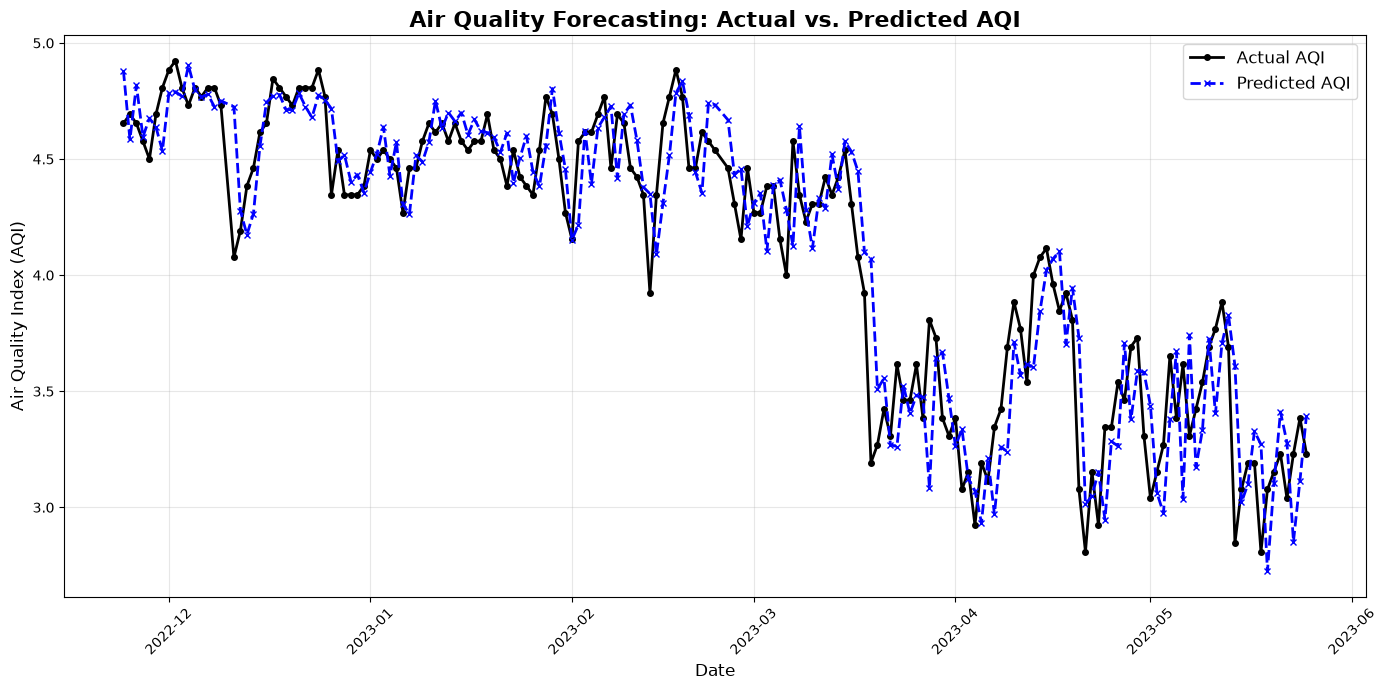

In [36]:
plt.figure(figsize=(14, 7))

plt.plot(dates_test, y_test, label='Actual AQI', color='black', linewidth=2, marker='o', markersize=4)

plt.plot(dates_test, predictions, label='Predicted AQI', color='blue', linestyle='--', linewidth=2, marker='x', markersize=4)

plt.title('Air Quality Forecasting: Actual vs. Predicted AQI', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Air Quality Index (AQI)', fontsize=12)

plt.xticks(rotation=45) 

plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()

plt.show()